# 📊 Employee Attrition Prediction Case Study
This notebook predicts employee churn using machine learning.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

## 2. Load Dataset

In [2]:
df = pd.read_csv('Case Study A.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,Yes,No,NaN,NaN,Research & Development,1.0,2.0,Medical,NaN,1994.0,...,3.0,80.0,NaN,1.0,2.0,NaN,1.0,1.0,0.0,0.0
1,30.0,NaN,Travel_Rarely,330.0,Human Resources,1.0,3.0,Life Sciences,NaN,1499.0,...,NaN,80.0,1.0,6.0,3.0,4.0,5.0,3.0,1.0,3.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2400.0,Yes,Travel_Rarely,59920.0,Sales,1160.0,4.0,Life Sciences,NaN,27.0,...,2.0,80.0,0.0,10.0,4.0,NaN,5.0,3.0,0.0,3.0


## 3. Dataset Info

In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1783 entries, 0 to 1782
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1423 non-null   object 
 1   Attrition                 1376 non-null   object 
 2   BusinessTravel            1365 non-null   object 
 3   DailyRate                 1412 non-null   object 
 4   Department                1384 non-null   object 
 5   DistanceFromHome          1418 non-null   object 
 6   Education                 1374 non-null   float64
 7   EducationField            1371 non-null   object 
 8   EmployeeCount             1370 non-null   float64
 9   EmployeeNumber            1381 non-null   float64
 10  EnvironmentSatisfaction   1374 non-null   float64
 11  Gender                    1369 non-null   object 
 12  HourlyRate                1371 non-null   float64
 13  JobInvolvement            1379 non-null   float64
 14  JobLevel

(1783, 35)

## 4. Missing Values

In [4]:
df.isnull().sum()

Age                         360
Attrition                   407
BusinessTravel              418
DailyRate                   371
Department                  399
DistanceFromHome            365
Education                   409
EducationField              412
EmployeeCount               413
EmployeeNumber              402
EnvironmentSatisfaction     409
Gender                      414
HourlyRate                  412
JobInvolvement              404
JobLevel                    420
JobRole                     410
JobSatisfaction             403
MaritalStatus               398
MonthlyIncome               414
MonthlyRate                 417
NumCompaniesWorked          412
Over18                      397
OverTime                    408
PercentSalaryHike           407
PerformanceRating           402
RelationshipSatisfaction    409
StandardHours               408
StockOptionLevel            404
TotalWorkingYears           401
TrainingTimesLastYear       416
WorkLifeBalance             405
YearsAtC

## 5. Handle Missing Values

In [5]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\sohai\AppData\Local\Temp\ipykernel_23752\2948044075.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


## 6. Remove Duplicates

In [7]:
df.drop_duplicates(inplace=True)

## 7. Encode Categorical Data

In [8]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

## 8. EDA

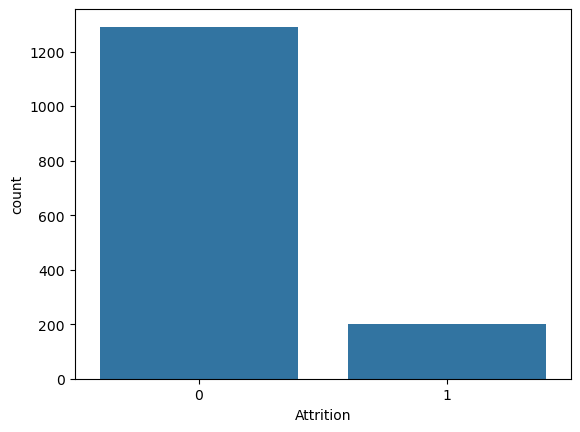

In [9]:
sns.countplot(x='Attrition', data=df)
plt.show()

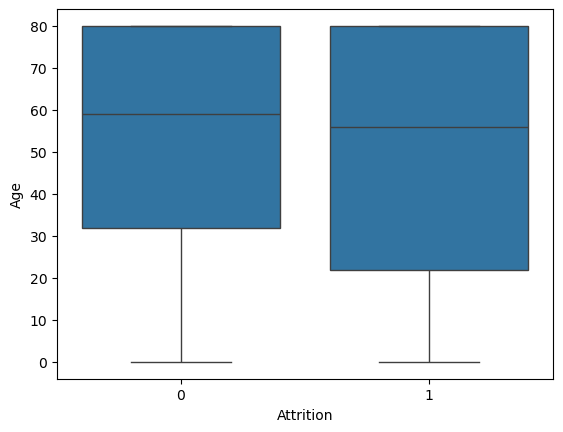

In [10]:
sns.boxplot(x='Attrition', y='Age', data=df)
plt.show()

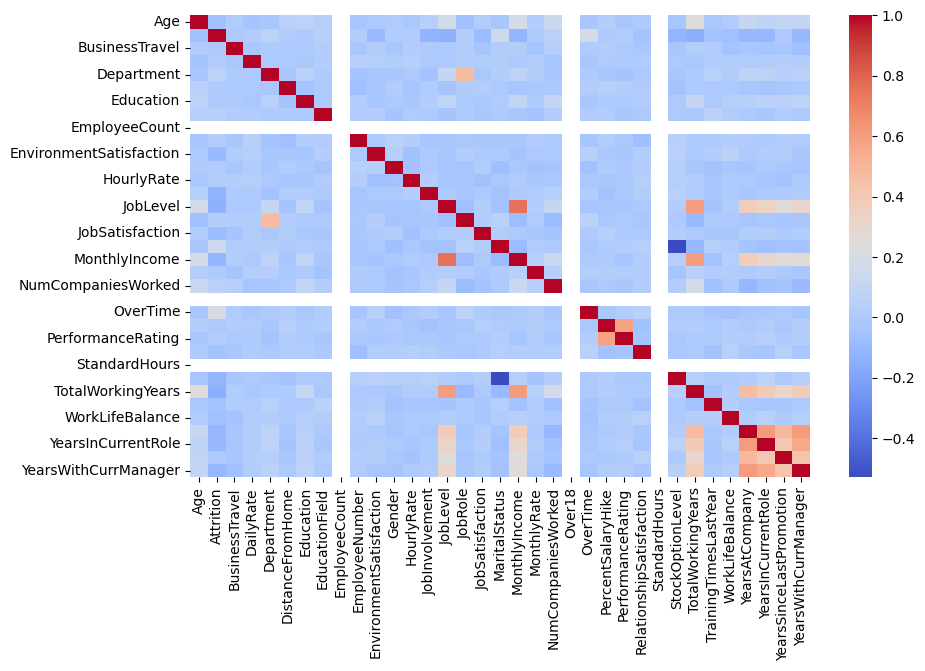

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## 9. Split Data

In [12]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 10. Train Model

In [13]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 11. Prediction

In [14]:
y_pred = model.predict(X_test)

## 12. Evaluation

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8327759197324415
Precision: 0.6666666666666666
Recall: 0.0392156862745098
F1 Score: 0.07407407407407407


## 13. Confusion Matrix

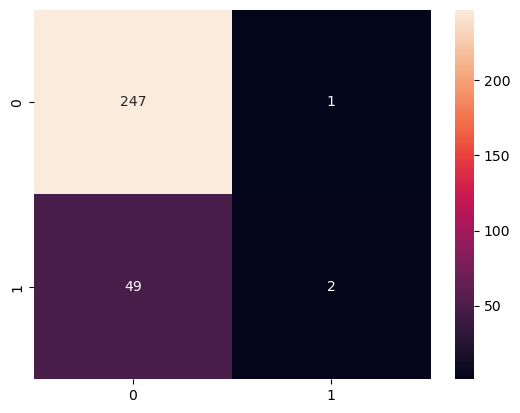

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## 14. Feature Importance

In [17]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

MonthlyIncome         0.071849
MonthlyRate           0.066510
Age                   0.055082
HourlyRate            0.050760
TotalWorkingYears     0.050710
EmployeeNumber        0.050506
DailyRate             0.050443
YearsAtCompany        0.044573
DistanceFromHome      0.041686
NumCompaniesWorked    0.039559
dtype: float64